CSV loaded successfully!
Summary statistics:


,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,230.555040,151.258469,116.444352,226.144375,219.568588,27.751788,55.013160,2.368093,3.229490,0.557740,161.741845,10.559568,975.915242,0.000535,0.001382,32.444403,33.543330,NaN
std,322.532347,250.956962,156.520714,317.346938,307.932510,4.758023,28.778732,1.462668,1.882565,0.268923,91.877217,5.915490,2.153977,0.023116,0.026350,10.998334,12.769277,NaN
min,-12.700000,0.000000,0.000000,0.000000,0.000000,14.900000,3.300000,0.000000,0.000000,0.000000,0.000000,0.000000,968.000000,0.000000,0.000000,13.100000,13.100000,NaN
25%,-2.200000,0.000000,0.000000,0.000000,0.000000,24.200000,26.500000,1.400000,1.900000,0.400000,74.800000,6.900000,975.000000,0.000000,0.000000,23.900000,23.600000,NaN
50%,2.100000,0.000000,2.500000,4.400000,4.300000,27.200000,59.300000,2.200000,2.900000,0.500000,199.100000,10.800000,976.000000,0.000000,0.000000,28.400000,28.400000,NaN
75%,442.400000,246.400000,215.700000,422.525000,411.000000,31.100000,80.800000,3.200000,4.400000,0.700000,233.500000,14.100000,977.000000,0.000000,0.000000,40.600000,43.000000,NaN
max,1424.000000,1004.500000,805.700000,1380.000000,1367.000000,41.400000,99.800000,16.100000,23.100000,4.700000,360.000000,86.900000,983.000000,1.000000,2.300000,70.400000,94.600000,NaN



Missing values per column:


Comments    525600
dtype: int64

Outliers detected: 9251 rows


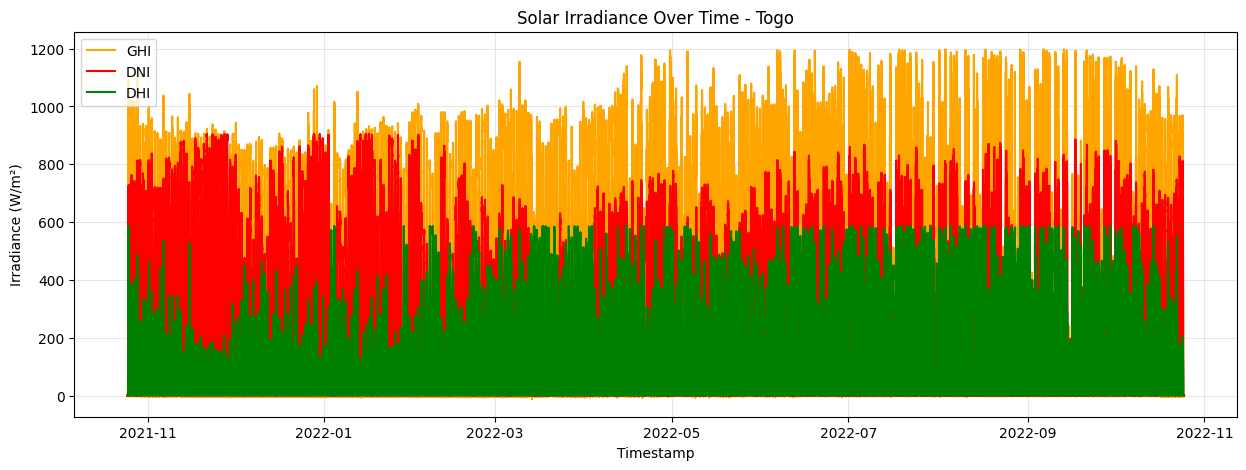

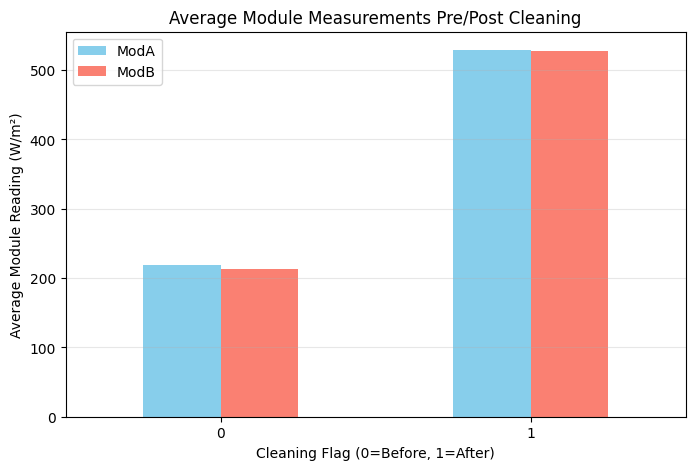

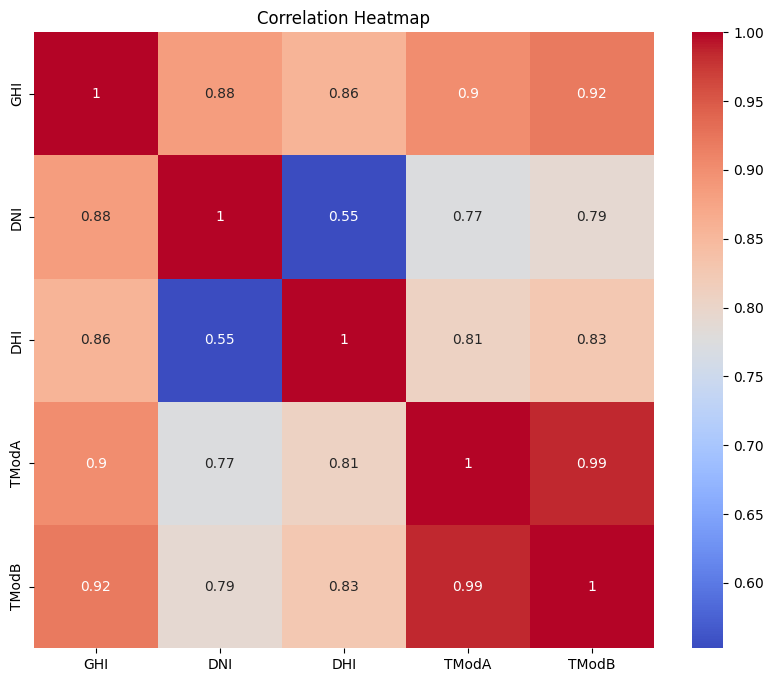

c:\Users\hamar\Downloads\solar\solar-challenge-week0\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


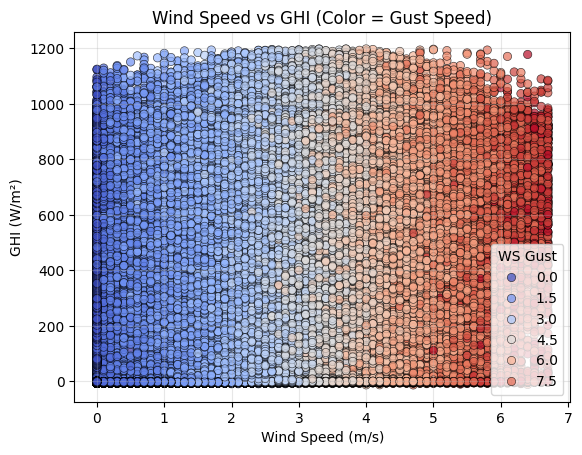

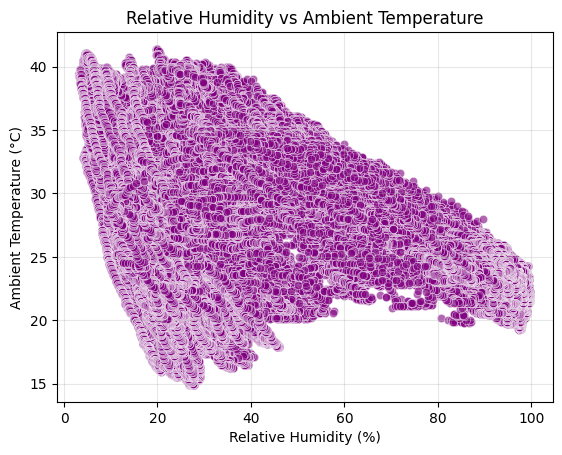

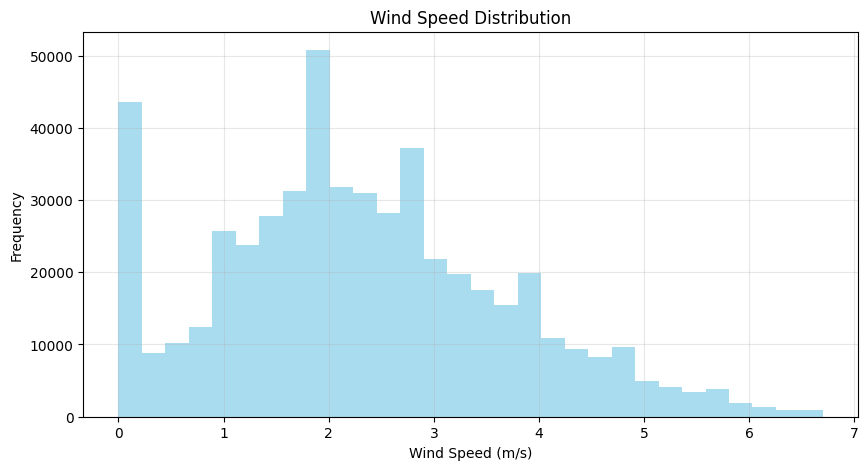

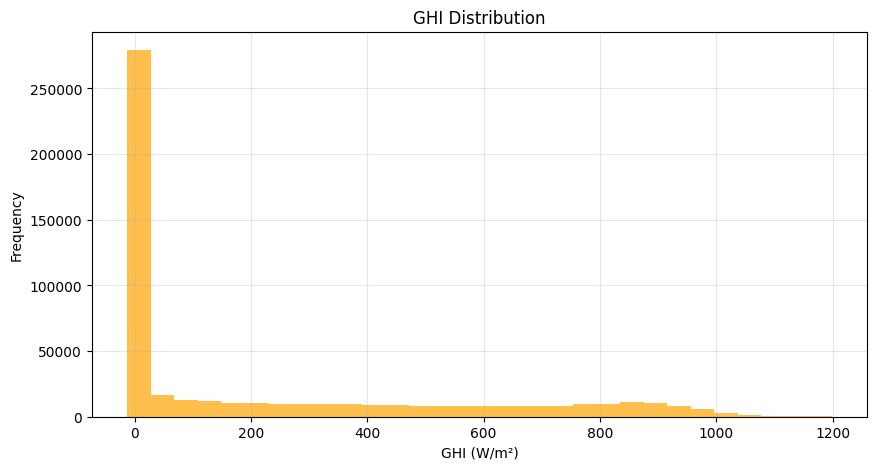

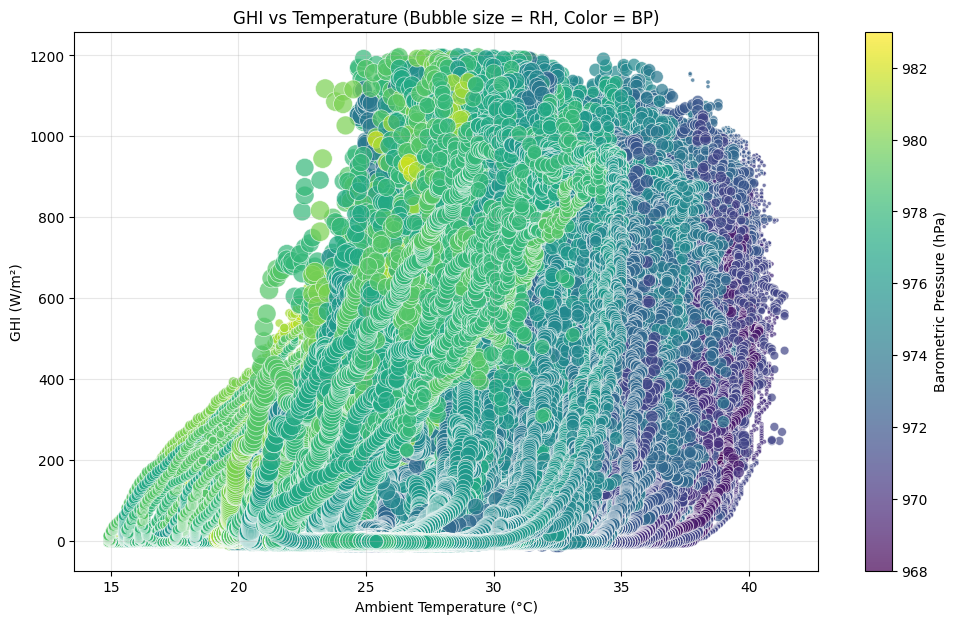

Cleaned dataset saved to ../data/togo_dapaong_clean.csv


In [2]:

# Togo Solar Data: EDA & Cleaning
# Import libraries
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Load dataset robustly
path = "../data/togo-dapaong_qc.csv"

if not os.path.exists(path):
    print(f"File not found at {path}")
    print("Current working directory:", os.getcwd())
    print("Top-level files:", os.listdir("."))

    if os.path.isdir("../data"):
        print("Files in data/:", os.listdir("../data"))

    candidates = glob.glob("**/togo*.csv", recursive=True)
    if candidates:
        print("Found candidate(s):", candidates)
        path = candidates[0]
        print("Using:", path)
    else:
        raise FileNotFoundError(
            f"Could not find 'togo-dapaong_qc.csv'. Looked at {os.path.abspath('../data')} and recursive search."
        )

df = pd.read_csv(path)
print("CSV loaded successfully!")
df.head()

# 2. Summary Statistics & Missing Values
print("Summary statistics:")
display(df.describe())

print("\nMissing values per column:")
missing_report = df.isna().sum()
display(missing_report[missing_report > 0])

# 3. Outlier Detection & Cleaning
numeric_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
z_scores = np.abs(stats.zscore(df[numeric_cols], nan_policy='omit'))
outlier_mask = (z_scores > 3).any(axis=1)
print(f"Outliers detected: {outlier_mask.sum()} rows")

df_clean = df.copy()
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())
df_clean = df_clean[~outlier_mask]

# 4. Time Series Analysis
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])
plt.figure(figsize=(15,5))
plt.plot(df_clean['Timestamp'], df_clean['GHI'], label='GHI', color='orange')
plt.plot(df_clean['Timestamp'], df_clean['DNI'], label='DNI', color='red')
plt.plot(df_clean['Timestamp'], df_clean['DHI'], label='DHI', color='green')
plt.xlabel("Timestamp")
plt.ylabel("Irradiance (W/m²)")
plt.title("Solar Irradiance Over Time - Togo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Cleaning Impact
avg_mod_cleaning = df_clean.groupby('Cleaning')[['ModA', 'ModB']].mean()
avg_mod_cleaning.plot(
    kind='bar',
    figsize=(8,5),
    title='Average Module Measurements Pre/Post Cleaning',
    color=['skyblue', 'salmon']
)
plt.ylabel("Average Module Reading (W/m²)")
plt.xlabel("Cleaning Flag (0=Before, 1=After)")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

# 6. Correlation & Relationships
plt.figure(figsize=(10,8))
sns.heatmap(df_clean[['GHI', 'DNI', 'DHI', 'TModA', 'TModB']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

sns.scatterplot(
    data=df_clean,
    x='WS',
    y='GHI',
    hue='WSgust',
    palette='coolwarm',
    alpha=0.7,
    edgecolor='k'
)
plt.title("Wind Speed vs GHI (Color = Gust Speed)")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("GHI (W/m²)")
plt.grid(True, alpha=0.3)
plt.legend(title='WS Gust')
plt.show()

sns.scatterplot(data=df_clean, x='RH', y='Tamb', color='purple', alpha=0.6)
plt.title("Relative Humidity vs Ambient Temperature")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Ambient Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.show()

# 7. Wind & Distribution Analysis
plt.figure(figsize=(10,5))
plt.hist(df_clean['WS'], bins=30, alpha=0.7, color='skyblue')
plt.title("Wind Speed Distribution")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,5))
plt.hist(df_clean['GHI'], bins=30, alpha=0.7, color='orange')
plt.title("GHI Distribution")
plt.xlabel("GHI (W/m²)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

# 8. Bubble Chart: GHI vs Tamb with RH
plt.figure(figsize=(12,7))
scatter = plt.scatter(
    df_clean['Tamb'],
    df_clean['GHI'],
    s=df_clean['RH']*2,
    c=df_clean['BP'],
    cmap='viridis',
    alpha=0.7,
    edgecolors='w',
    linewidth=0.5
)
plt.colorbar(scatter, label='Barometric Pressure (hPa)')
plt.xlabel("Ambient Temperature (°C)")
plt.ylabel("GHI (W/m²)")
plt.title("GHI vs Temperature (Bubble size = RH, Color = BP)")
plt.grid(True, alpha=0.3)
plt.show()

# 9. Export Cleaned Data
output_path = "../data/togo_dapaong_clean.csv"
df_clean.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to {output_path}")
